# Rumelhart, Hinton & Williams (1986) family-tree network

Self-contained reproduction of the family-tree example from *Learning
representations by back-propagating errors* (Nature **323**, 1986): a five-layer
net that learns 24-person / 12-relation triples from two isomorphic family
trees, plus visualizations of the units and weights (Figs. 3 and 4).

Runs top to bottom on Colab with nothing but this file.

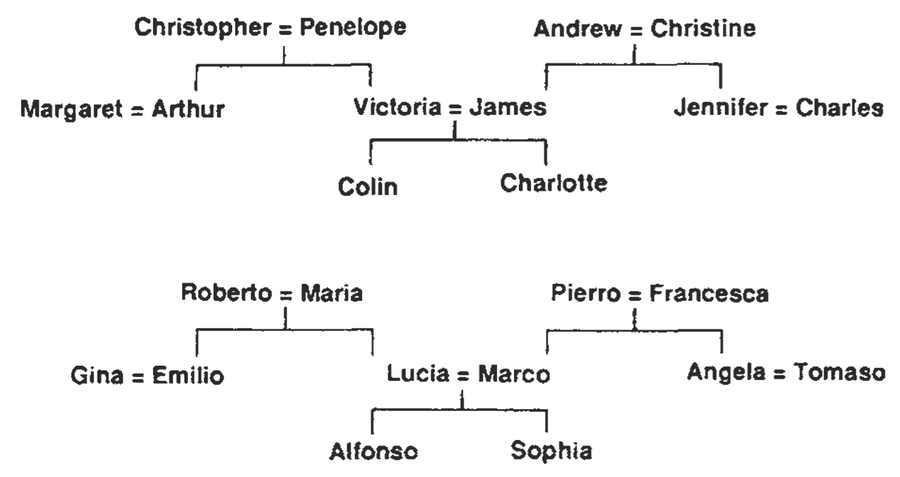

*`=` marks a marriage; brackets link parents to children.*

In [ ]:
%pip install -q "nnsight>=0.4,<0.5"  # torch / matplotlib are preinstalled on Colab

import random, statistics
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from nnsight import NNsight

## 1. Dataset

Two isomorphic families. From gender + marriages + parent links we derive every
`(x, relation, y)` triple ("y is the *relation* of x"). The 112 triples collapse
to **104 `(person, relation)` query patterns** -- 8 have two correct answers
(a child with two aunts / uncles).

In [ ]:
male = {"Christopher", "Andrew", "Arthur", "James", "Charles", "Colin",
        "Roberto", "Pierro", "Emilio", "Marco", "Tomaso", "Alfonso"}
female = {"Penelope", "Christine", "Margaret", "Victoria", "Jennifer", "Charlotte",
          "Maria", "Francesca", "Gina", "Lucia", "Angela", "Sophia"}
people = sorted(male | female)

# tree order, English and Italian isomorphic position-for-position
english = ["Christopher", "Penelope", "Andrew", "Christine", "Margaret", "Arthur",
           "Victoria", "James", "Jennifer", "Charles", "Colin", "Charlotte"]
italian = ["Roberto", "Maria", "Pierro", "Francesca", "Gina", "Emilio",
           "Lucia", "Marco", "Angela", "Tomaso", "Alfonso", "Sophia"]

marriages = [  # (husband, wife)
    ("Christopher", "Penelope"), ("Andrew", "Christine"), ("Arthur", "Margaret"),
    ("James", "Victoria"), ("Charles", "Jennifer"),
    ("Roberto", "Maria"), ("Pierro", "Francesca"), ("Emilio", "Gina"),
    ("Marco", "Lucia"), ("Tomaso", "Angela"),
]
parents = {  # child -> (parent, parent)
    "Arthur": ("Christopher", "Penelope"), "Victoria": ("Christopher", "Penelope"),
    "James": ("Andrew", "Christine"), "Jennifer": ("Andrew", "Christine"),
    "Colin": ("James", "Victoria"), "Charlotte": ("James", "Victoria"),
    "Emilio": ("Roberto", "Maria"), "Lucia": ("Roberto", "Maria"),
    "Marco": ("Pierro", "Francesca"), "Angela": ("Pierro", "Francesca"),
    "Alfonso": ("Marco", "Lucia"), "Sophia": ("Marco", "Lucia"),
}
relationships = ["has_father", "has_mother", "has_husband", "has_wife",
                 "has_son", "has_daughter", "has_uncle", "has_aunt",
                 "has_brother", "has_sister", "has_nephew", "has_niece"]

In [ ]:
def spouse(p):
    for h, w in marriages:
        if p == h: return w
        if p == w: return h
    return None

def children(p):
    return [c for c, ps in parents.items() if p in ps]

def siblings(p):
    ps = parents.get(p)
    return sorted(c for c, cps in parents.items() if ps and cps == ps and c != p)

def build_triples():
    tr = set()
    for p in people:
        for par in parents.get(p, ()):
            tr.add((p, "has_father" if par in male else "has_mother", par))
        s = spouse(p)
        if s:
            tr.add((p, "has_husband" if s in male else "has_wife", s))
        for c in children(p):
            tr.add((p, "has_son" if c in male else "has_daughter", c))
        for sib in siblings(p):
            tr.add((p, "has_brother" if sib in male else "has_sister", sib))
        unc, aunt = set(), set()
        for par in parents.get(p, ()):
            for sib in siblings(par):
                (unc if sib in male else aunt).add(sib)
                sp = spouse(sib)
                if sp:
                    (unc if sp in male else aunt).add(sp)
        for u in unc:  tr.add((p, "has_uncle", u))
        for a in aunt: tr.add((p, "has_aunt", a))
    for x, rel, y in list(tr):
        if rel in ("has_uncle", "has_aunt"):
            tr.add((y, "has_nephew" if x in male else "has_niece", x))
    return sorted(tr)

triples = build_triples()
print(len(people), "people,", len(triples), "triples")

In [ ]:
pi = {n: i for i, n in enumerate(people)}
ri = {r: i for i, r in enumerate(relationships)}

targets = defaultdict(lambda: torch.zeros(len(people)))
for x, rel, y in triples:
    targets[(pi[x], ri[rel])][pi[y]] = 1.0

items = sorted(targets.items())
P = torch.tensor([p for (p, _), _ in items])
R = torch.tensor([r for (_, r), _ in items])
Y = torch.stack([t for _, t in items])
print(len(triples), "triples ->", len(items), "query patterns")

# hold out 4 single-answer triples (multi-answer ones can't be reached by
# generalization, so they'd only cap the test score)
single = [i for i in range(len(items)) if Y[i].sum() == 1]
random.Random(1).shuffle(single)
held = set(single[:4])
test_idx = torch.tensor(sorted(held))
train_idx = torch.tensor([i for i in range(len(items)) if i not in held])

## 2. Network

```
one-hot person1 (24) --> person_encoding (6) --.
                                               |-- layer3 (12) --> layer4 (6) --> decoder (24)
one-hot relation (12) -> relation_encoding (6) -'
```

Logistic sigmoid units with biases throughout; init `uniform(-0.3, 0.3)`.

In [ ]:
class FamilyTreeNet(nn.Module):
    def __init__(self, n_people=24, n_relations=12, hidden_size=6):
        super().__init__()
        self.n_people = n_people
        self.n_relations = n_relations
        self.person_encoding = nn.Linear(n_people, hidden_size)
        self.relation_encoding = nn.Linear(n_relations, hidden_size)
        self.layer3 = nn.Linear(2 * hidden_size, 2 * hidden_size)
        self.layer4 = nn.Linear(2 * hidden_size, hidden_size)
        self.decoder = nn.Linear(hidden_size, n_people)
        for w in self.parameters():
            nn.init.uniform_(w, -0.3, 0.3)

    def forward(self, person, relation):
        p = F.one_hot(person, self.n_people).float()
        r = F.one_hot(relation, self.n_relations).float()
        p = torch.sigmoid(self.person_encoding(p))
        r = torch.sigmoid(self.relation_encoding(r))
        h = torch.sigmoid(self.layer3(torch.cat([p, r], dim=-1)))
        h = torch.sigmoid(self.layer4(h))
        return torch.sigmoid(self.decoder(h))

print(FamilyTreeNet())
print(sum(p.numel() for p in FamilyTreeNet().parameters()), "parameters")

## 3. Train

The paper's recipe:

* **batch** gradient descent -- accumulate over all cases, then one step
* error `E = 1/2 * sum_c sum_j (y - d)**2` (a sum, halved, not a mean)
* **error-tolerance band**: zero error once an output is > 0.8 where it should be
  on, or < 0.2 where it should be off
* momentum schedule `eps,alpha` = `0.005,0.5` for 20 sweeps then `0.01,0.9`

Deviations: ~30k sweeps (not 1500 -- slower here); no weight decay (the paper's
0.2%/step decay was only for weight legibility and prevents learning here).

This minimal net hits local minima (the paper says so), so a single run isn't
meaningful -- we train a few and report the **mean held-out accuracy**, then keep
the best one to inspect. (Lower `N_MODELS` / `SWEEPS` if it's slow.)

In [ ]:
def band_sse(out, target):
    """Half sum-of-squared-error with the paper's 0.2 / 0.8 tolerance band."""
    err = out - target
    settled = ((target == 1) & (out > 0.8)) | ((target == 0) & (out < 0.2))
    return 0.5 * err.masked_fill(settled, 0.0).pow(2).sum()

def accuracy(net, idx):
    with torch.no_grad():
        out = net(P[idx], R[idx])
    return (((out > 0.5) == (Y[idx] > 0.5)).all(dim=1)).float().mean().item()

def train_one(seed, sweeps):
    torch.manual_seed(seed)
    net = FamilyTreeNet()
    opt = torch.optim.SGD(net.parameters(), lr=0.005, momentum=0.5)
    for sweep in range(1, sweeps + 1):
        if sweep == 21:
            for g in opt.param_groups:
                g["lr"], g["momentum"] = 0.01, 0.9
        opt.zero_grad()
        band_sse(net(P[train_idx], R[train_idx]), Y[train_idx]).backward()
        opt.step()
    return net

N_MODELS, SWEEPS = 5, 30_000
runs, held_scores = [], []
for seed in range(N_MODELS):
    n = train_one(seed, SWEEPS)
    tr, te = accuracy(n, train_idx), accuracy(n, test_idx)
    runs.append((te, tr, n)); held_scores.append(te)
    print(f"seed {seed}  train {tr:.2f}  held-out {te:.2f}")

print(f"\nheld-out accuracy: {statistics.mean(held_scores):.2f} "
      f"+/- {statistics.pstdev(held_scores):.2f}  over {N_MODELS} models")
net = max(runs)[2]  # keep the best for inspection below

In [ ]:
# best model's predictions on the 4 held-out queries
with torch.no_grad():
    out = net(P[test_idx], R[test_idx])
names = lambda v: [people[j] for j in range(len(people)) if v[j] > 0.5]
for k, i in enumerate(test_idx.tolist()):
    print(f"{people[int(P[i])]:12s} {relationships[int(R[i])]:12s} -> "
          f"pred {names(out[k])}  actual {names(Y[i])}")

## 4. Inspect with NNsight

`NNsight` wraps the net so any module's output can be read (or edited) during a
forward pass. Weights are just tensors on the modules.

In [ ]:
person, relation = people.index("Colin"), relationships.index("has_aunt")

m = NNsight(net)
with m.trace(torch.tensor([person]), torch.tensor([relation])):
    enc = m.person_encoding.output.save()
    dec = m.decoder.output.save()

print("person_encoding (pre-sigmoid):", enc[0])
print("decoder        (pre-sigmoid):", dec[0].round(decimals=2))

### Fig. 3 -- unit activity for one query

Stacked blocks: 24 + 12 input, then the two 6-unit encodings, the 12-unit central
layer, the 6-unit penultimate layer, and the 24 output units. Square area = unit
activation; red boxes mark the correct answers.

In [ ]:
LAYERS = ["person_encoding", "relation_encoding", "layer3", "layer4", "decoder"]

def _col_order():
    pos = {n: i for i, n in enumerate(people)}
    return [pos[n] for n in english], [pos[n] for n in italian]

@torch.no_grad()
def activations(net, person, relation):
    """layer name -> 1-D tensor of post-sigmoid unit activities (via NNsight)."""
    p, r = torch.tensor([int(person)]), torch.tensor([int(relation)])
    m = NNsight(net)
    with m.trace(p, r):
        saved = {name: getattr(m, name).output.save() for name in LAYERS}
    return {
        "person_in": F.one_hot(p, net.n_people).float()[0],
        "relation_in": F.one_hot(r, net.n_relations).float()[0],
        "person_encoding": torch.sigmoid(saved["person_encoding"])[0],
        "relation_encoding": torch.sigmoid(saved["relation_encoding"])[0],
        "central": torch.sigmoid(saved["layer3"])[0],
        "person2": torch.sigmoid(saved["layer4"])[0],
        "output": torch.sigmoid(saved["decoder"])[0],
    }

def print_activations(net, person, relation, threshold=0.5):
    a = activations(net, person, relation)
    print(f"{people[int(person)]} --{relationships[int(relation)]}-->")
    rows = [("person in  (24)", a["person_in"]), ("relation in(12)", a["relation_in"]),
            ("person enc  (6)", a["person_encoding"]), ("relation enc(6)", a["relation_encoding"]),
            ("central    (12)", a["central"]), ("person2     (6)", a["person2"]),
            ("output     (24)", a["output"])]
    for name, vec in rows:
        print(f"  {name}  " + " ".join(f"{v:4.2f}" for v in vec.tolist()))
    print("  ->", [people[i] for i, v in enumerate(a["output"]) if v > threshold])

def _block(ax, vals, x, y, nrow, ncol, *, signed=False, vmax=None,
           cell=1.0, gap=0.14, box="0.5", bg="0.15"):
    vals = [float(v) for v in vals]
    vmax = vmax or max((abs(v) for v in vals), default=1.0) or 1.0
    ax.add_patch(Rectangle((x, y), ncol * cell, nrow * cell, facecolor=bg,
                           edgecolor=box, lw=1.0, zorder=0))
    for k, v in enumerate(vals):
        rr, cc = divmod(k, ncol)
        s = (cell - gap) * (abs(v) / vmax) ** 0.5
        if s <= 0:
            continue
        ax.add_patch(Rectangle((x + cc * cell + (cell - s) / 2,
                                y + rr * cell + (cell - s) / 2), s, s, zorder=1,
                               facecolor=("white" if v >= 0 or not signed else "black"),
                               edgecolor="none"))

def show_activations(net, person, relation, answer=None, figsize=(9, 6)):
    a = activations(net, person, relation)
    eng, ita = _col_order()
    by_tree = lambda vec: [vec[i] for i in eng] + [vec[i] for i in ita]

    fig, ax = plt.subplots(figsize=figsize)
    xr = 13.0
    for label, y, vec, nr, nc, x in [
        ("person 2 (output)", 0.0, by_tree(a["output"]), 2, 12, 0.0),
        ("person 2 encoding", 2.7, a["person2"], 1, 6, 3.0),
        ("central layer", 4.4, a["central"], 1, 12, 0.0),
    ]:
        _block(ax, vec, x, y, nr, nc)
        ax.text(-0.6, y + nr / 2, label, ha="right", va="center", color="0.25", fontsize=8)

    _block(ax, a["person_encoding"], 3.0, 6.1, 1, 6)
    _block(ax, a["relation_encoding"], xr, 6.1, 1, 6)
    ax.text(-0.6, 6.6, "person / relation encoding", ha="right", va="center", color="0.25", fontsize=8)

    _block(ax, by_tree(a["person_in"]), 0.0, 7.8, 2, 12)
    _block(ax, [a["relation_in"][i] for i in range(12)], xr, 7.8, 2, 6)
    ax.text(-0.6, 8.8, "person 1 / relation (input)", ha="right", va="center", color="0.25", fontsize=8)

    for nm in (answer or []):
        k = (english + italian).index(nm)
        rr, cc = divmod(k, 12)
        ax.add_patch(Rectangle((cc, rr), 1, 1, fill=False, edgecolor="#e45", lw=1.6))

    ax.set_xlim(-6, 20); ax.set_ylim(0, 10.2)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{people[int(person)]}  --{relationships[int(relation)]}-->", fontsize=10)
    fig.tight_layout()
    return fig

In [ ]:
print_activations(net, person, relation)
show_activations(net, person, relation, answer=["Jennifer", "Margaret"]);

### Fig. 4 -- learned weights

`show_weights` is a generic Hinton diagram (white = positive, black = negative,
area = magnitude). `show_person_encoding_weights` applies it to the 24->6
person-encoding weights, English row over the isomorphic Italian row -- look for
a unit that splits English/Italian, one that splits by generation, one by branch.

In [ ]:
def show_weights(weight, row_labels=None, col_labels=None, title=None, figsize=None, vmax=None):
    W = weight.detach().cpu()
    nrow, ncol = W.shape
    fig, ax = plt.subplots(figsize=figsize or (ncol * 0.35 + 2, nrow * 0.35 + 1))
    _block(ax, W.flatten().tolist(), 0, 0, nrow, ncol, signed=True, vmax=vmax)
    ax.set_xticks([i + 0.5 for i in range(ncol)] if col_labels else [])
    ax.set_yticks([i + 0.5 for i in range(nrow)] if row_labels else [])
    if col_labels: ax.set_xticklabels(col_labels, rotation=90, fontsize=7)
    if row_labels: ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_xlim(0, ncol); ax.set_ylim(0, nrow)
    ax.invert_yaxis(); ax.set_aspect("equal")
    if title: ax.set_title(title, fontsize=10)
    fig.tight_layout()
    return fig

def show_person_encoding_weights(net, figsize=(8, 7)):
    W = net.person_encoding.weight.detach().cpu()          # [6, 24]
    eng, ita = _col_order()
    vmax = W.abs().max().item()
    fig, axes = plt.subplots(W.shape[0], 1, figsize=figsize)
    for u, ax in enumerate(axes):
        _block(ax, [W[u, i] for i in eng] + [W[u, i] for i in ita], 0, 0, 2, 12,
               signed=True, vmax=vmax)
        ax.text(-0.5, 1.0, f"unit {u + 1}", ha="right", va="center", color="0.25", fontsize=8)
        ax.set_xlim(-4, 12); ax.set_ylim(0, 2)
        ax.invert_yaxis(); ax.set_aspect("equal"); ax.axis("off")
    axes[0].set_title("person-encoding weights  (top: English,  bottom: Italian)", fontsize=10)
    fig.tight_layout()
    return fig

show_person_encoding_weights(net)
show_weights(net.decoder.weight, col_labels=[f"h{i}" for i in range(6)],
             row_labels=people, title="decoder weights (6 -> 24)");